# This notebook concern ML project about insurance charges amount predictions.


**Let start with importing libraries which allow to prepare data to further actions.**


In [3]:
!pip install xgboost

In [324]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.compose import ColumnTransformer,  TransformedTargetRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, PredefinedSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

import joblib


RANDOM_STATE = 88

OUTPUT_DIR = Path("outputs")
MODEL_DIR = Path("models")

OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

Now we import data from single csv file.

In [6]:
DATA_PATH = Path("insurance.csv")  # Relative path to the dataset (must sit next to this notebook)
df = pd.read_csv(DATA_PATH)        # Read the CSV into a pandas DataFrame — our primary data structure

In [7]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
# Count NaN (missing) values per column — any non-zero count requires handling before modelling
print("Missing values:")
display(df.isna().sum())

# Count exact duplicate rows — keeping them can bias training (model sees same example twice)
print("Duplicated rows:", df.duplicated().sum())

Missing values:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicated rows: 1


In [10]:
# Remove all duplicate rows, keeping only the first occurrence of each
# reset_index(drop=True): re-numbers the index from 0 to n-1 so it stays contiguous after row removal
df = df.drop_duplicates().reset_index(drop=True)

In [11]:
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


**Now our data are clear and ready to use. It means that we can skip part of handling with missing data.**




**Lets move to the Exploratory Data Analysis. First of all we want to check how our data look on some charts and also we want to check outliers.**


In [15]:
# Compute the skewness of the 'charges' distribution
# Skewness = 0  → perfectly symmetric (like a normal distribution)
# Skewness > 0  → right-skewed: a long tail stretches towards high values
# Rule of thumb: |skewness| > 0.5 suggests meaningful skew worth addressing
df["charges"].skew()

1.5153909108403483

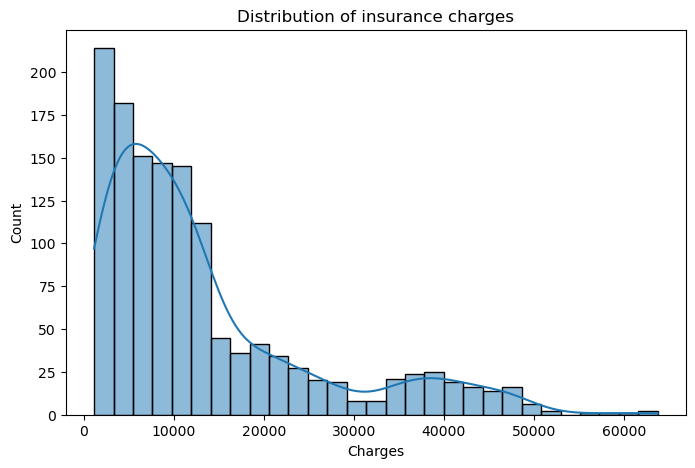

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df["charges"], kde=True)
plt.title("Distribution of insurance charges")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()



<Figure size 800x500 with 0 Axes>

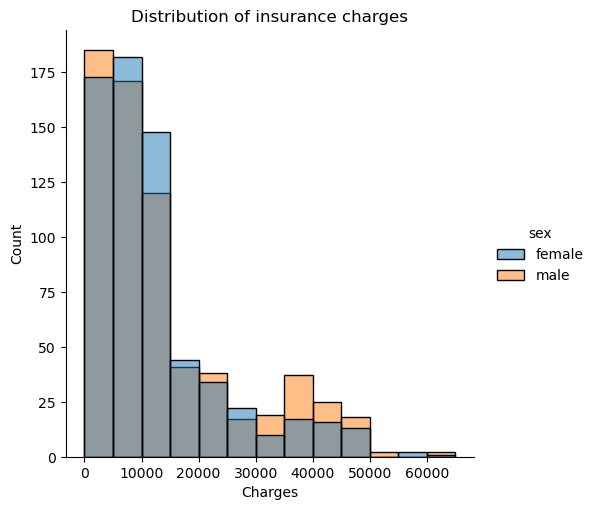

In [17]:
bins=np.arange(0,70000,5000)
plt.figure(figsize=(8, 5))
sns.displot(data=df, x=df["charges"], bins=bins, hue=df["sex"])
plt.title("Distribution of insurance charges")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()


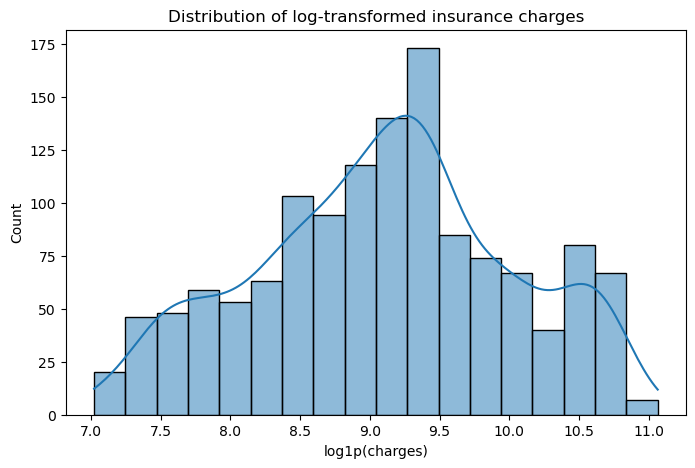

In [18]:
# log1p(x) = log(1 + x) — applies a logarithmic transformation to reduce right skew
# Adding 1 before taking the log prevents issues when x = 0 (log(0) = -inf)
# A more symmetric distribution can help linear models fit better
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df["charges"]), kde=True)
plt.title("Distribution of log-transformed insurance charges")
plt.xlabel("log1p(charges)")
plt.ylabel("Count")
plt.show()

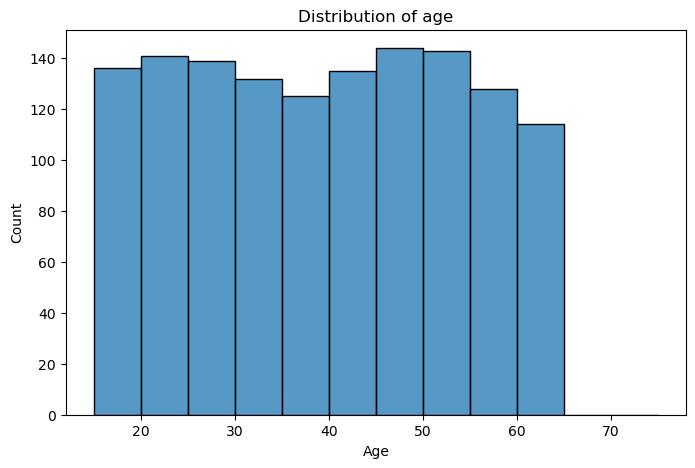

In [19]:
age = np.arange(15, 80, 5)  # Bin edges from age 15 to 80 in 5-year steps

plt.figure(figsize=(8, 5))
# Roughly uniform age distribution = data represents all age groups fairly (no age bias)
sns.histplot(df["age"], bins=age)
plt.title("Distribution of age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

C:\Users\adamx\AppData\Local\Temp\ipykernel_19440\2568095509.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x="bmi", y="charges", palette="viridis")


<Axes: xlabel='bmi', ylabel='charges'>

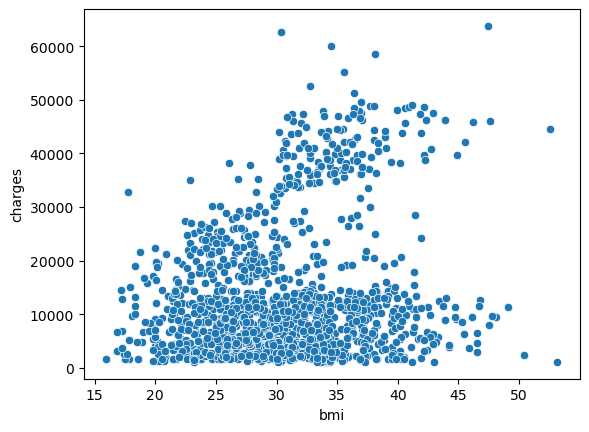

In [20]:
# Scatter plot: BMI on x-axis vs insurance charges on y-axis
# Looking for a linear or non-linear relationship between body mass index and cost
sns.scatterplot(data=df, x="bmi", y="charges", palette="viridis")

<Axes: xlabel='bmi', ylabel='charges'>

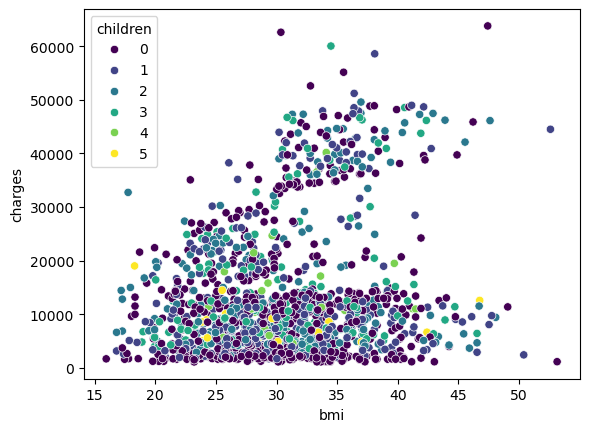

In [21]:
# Same BMI vs charges, now coloured by number of children
# Checks whether family size interacts with BMI to push costs higher
sns.scatterplot(data=df, x="bmi", y="charges", hue="children", palette="viridis")

<Axes: xlabel='bmi', ylabel='charges'>

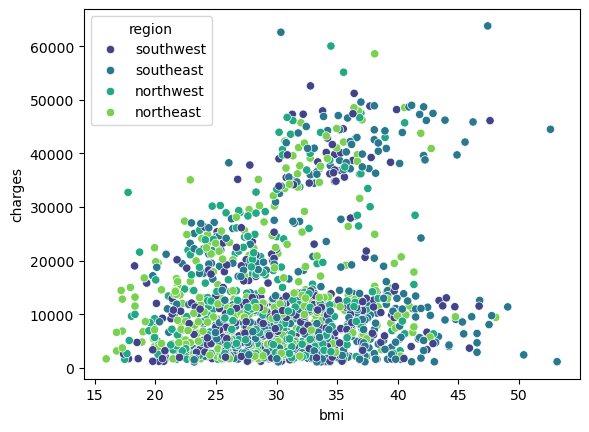

In [22]:
# Colour by US region — checks for regional cost differences across the BMI range
sns.scatterplot(data=df, x="bmi", y="charges", hue="region", palette="viridis")

<Axes: xlabel='bmi', ylabel='charges'>

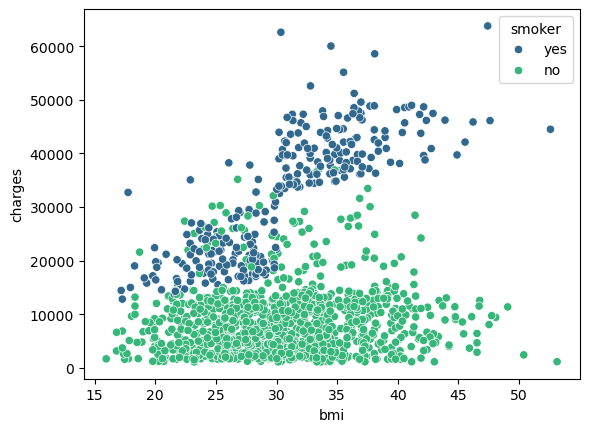

In [23]:
# Split by smoker status — the most revealing view:
# Two distinct clusters emerge showing smoking dramatically raises insurance costs
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", palette="viridis")

<Axes: xlabel='bmi', ylabel='charges'>

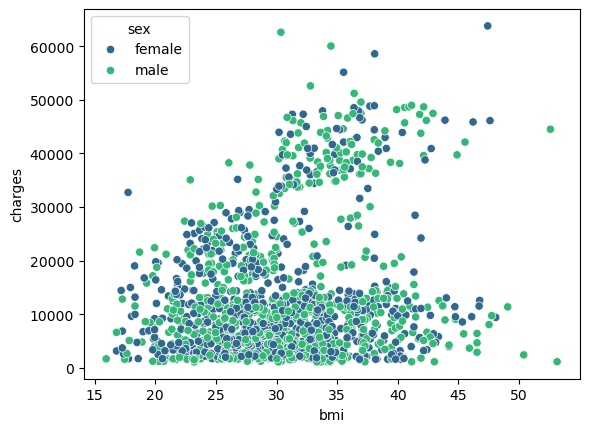

In [24]:
# Split by sex — checking if the gender pay gap exists in insurance charges
sns.scatterplot(data=df, x="bmi", y="charges", hue="sex", palette="viridis")

<Axes: xlabel='age', ylabel='charges'>

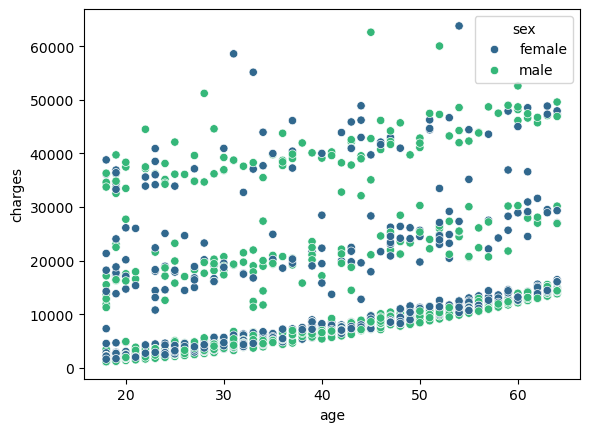

In [25]:
# Age vs charges split by sex — confirms that age raises costs for both genders similarly
sns.scatterplot(data=df, x="age", y="charges", hue="sex", palette="viridis")

<Axes: xlabel='age', ylabel='charges'>

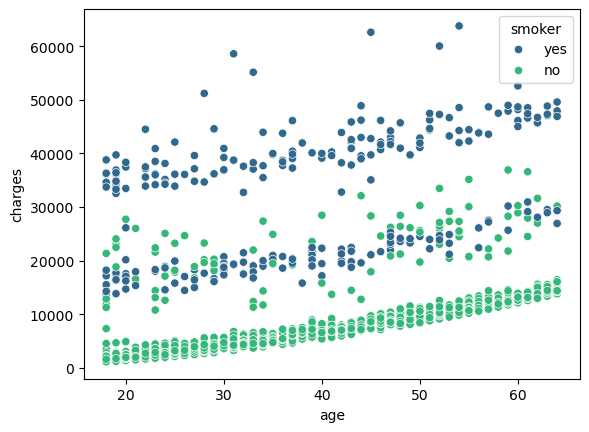

In [26]:
# Age vs charges coloured by smoker status — shows that smokers pay more at every age
sns.scatterplot(data=df, x="age" , y="charges", hue="smoker", palette="viridis")

**We see the first  2 trends. People who smoke cigarettes have significantly higher insurance charges. Furthermore, the higher the age, the higher the insurance fees.**


**We can see that almost half of the people have charges less than or equal to 10,000. Moreover, we can see that people are evenly distributed in terms of age, and there are no strong deviations in the distribution of charges with respect to sex.**

**Let see how boxplots looks.**

Text(0.5, 1.0, 'Charges divided by sex')

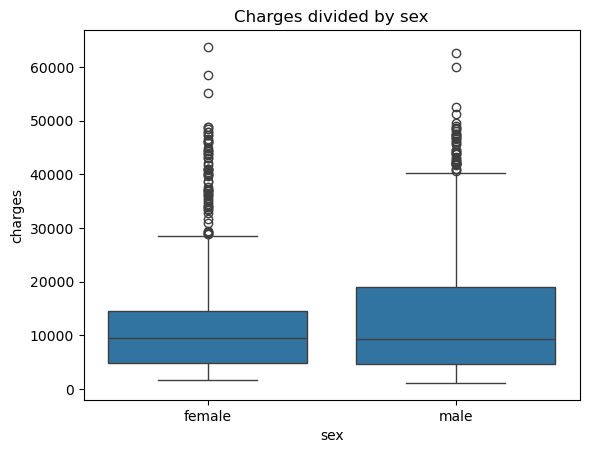

In [31]:
# Box plot breakdown:
#   Box    = interquartile range (IQR): 25th to 75th percentile
#   Line   = median (50th percentile)
#   Whiskers = 1.5 × IQR from the box edges
#   Dots   = outliers (points beyond the whiskers)
# Comparing charge distributions between male and female
sns.boxplot(data=df, x="sex", y="charges")
plt.title("Charges divided by sex")

Text(0.5, 1.0, 'Charges divided by yes/no smokers')

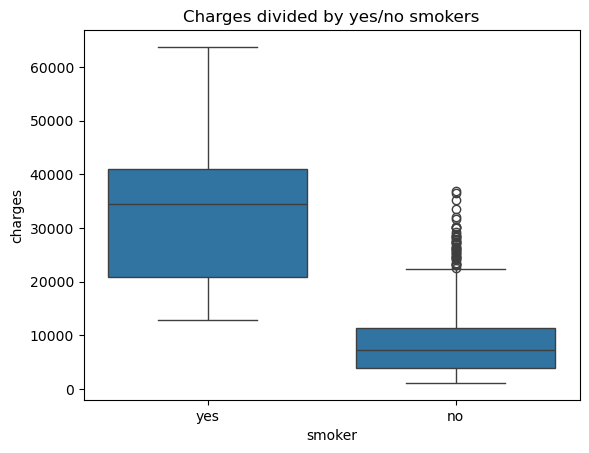

In [32]:
# Boxplot makes the enormous gap between smoker and non-smoker charges immediately visible
# Median smoker charge is roughly 3-4x higher than non-smoker
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Charges divided by yes/no smokers")

In [33]:
# Separate the dataset into two subsets for more granular analysis
smokers_data     = df[df["smoker"] == "yes"]   # 274 rows where smoker == yes
non_smokers_data = df[df["smoker"] == "no"]    # remaining rows where smoker == no

Text(0.5, 1.0, 'Smokers charges divided by sex')

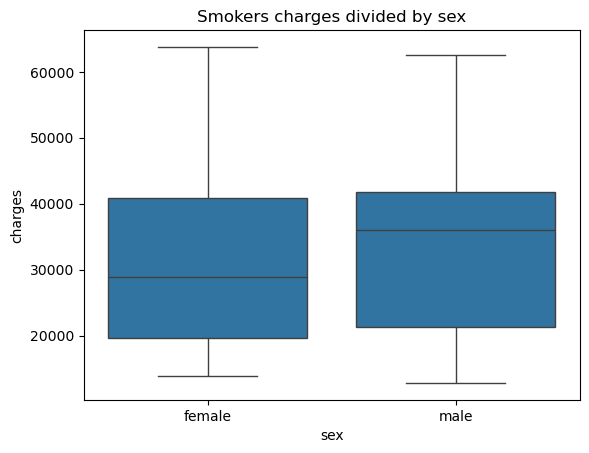

In [34]:
# Among smokers only: do men pay significantly more than women?
sns.boxplot(data=smokers_data, x="sex", y="charges")
plt.title("Smokers charges divided by sex")

Text(0.5, 1.0, 'Non smokers charges divided by sex')

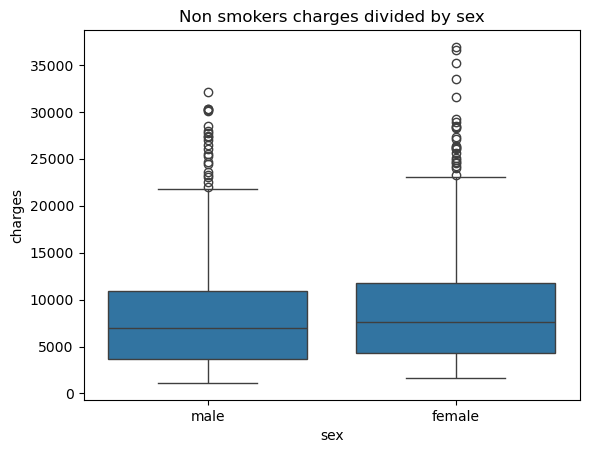

In [35]:
# Among non-smokers only: sex-based charge comparison (much smaller overall values)
sns.boxplot(data=non_smokers_data, x="sex", y="charges")
plt.title("Non smokers charges divided by sex")

Text(0.5, 1.0, 'Non smokers bmi vs charges with children number separation')

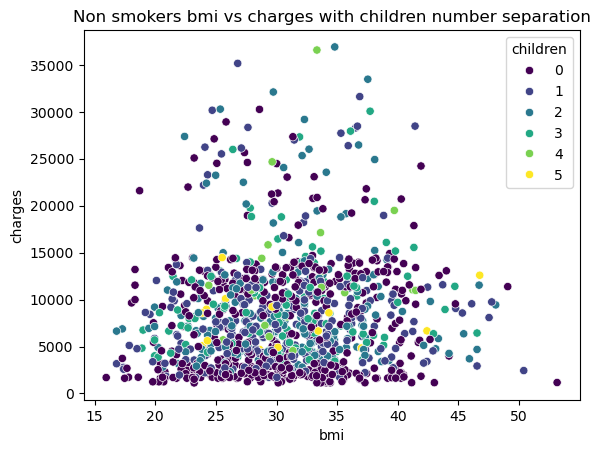

In [36]:
# For non-smokers: do BMI + number of children together drive costs up?
sns.scatterplot(data=non_smokers_data, x="bmi", y="charges", hue="children", palette="viridis")
plt.title("Non smokers bmi vs charges with children number separation")

Text(0.5, 1.0, 'Non smokers bmi vs charges with region separation')

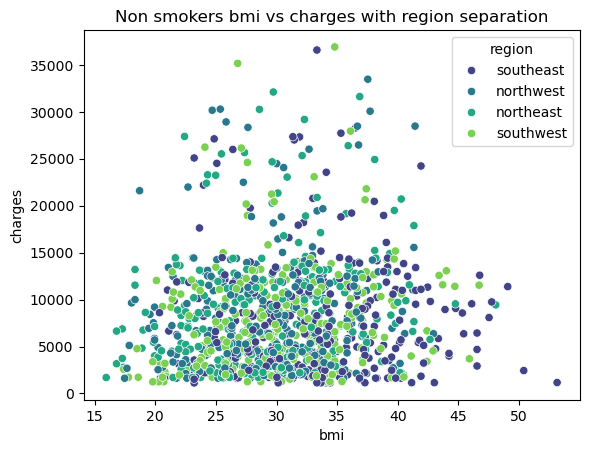

In [37]:
# For non-smokers: does geographic region interact with BMI to affect charges?
sns.scatterplot(data=non_smokers_data, x="bmi", y="charges", hue="region", palette="viridis")
plt.title("Non smokers bmi vs charges with region separation")

Text(0.5, 1.0, 'Smokers bmi vs charges with children number separation')

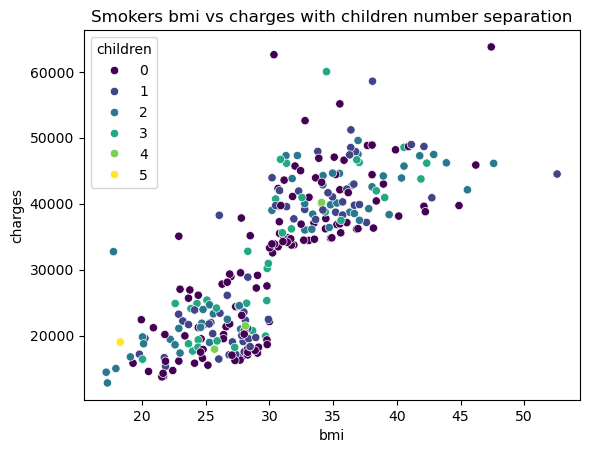

In [38]:
# For smokers: higher BMI (obesity) combined with smoking — the most expensive group?
sns.scatterplot(data=smokers_data, x="bmi", y="charges", hue="children", palette="viridis")
plt.title("Smokers bmi vs charges with children number separation")

Text(0.5, 1.0, 'Charges vs region')

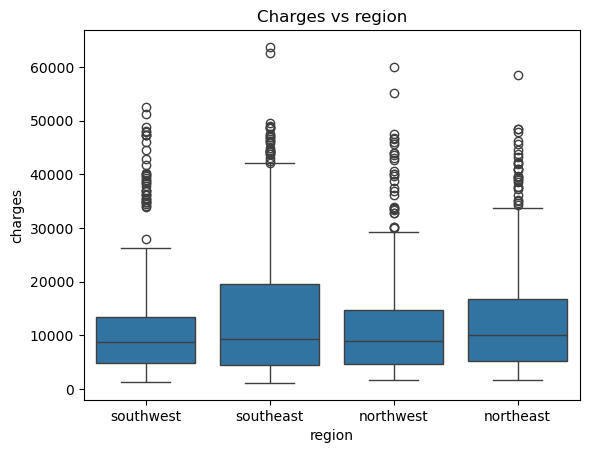

In [39]:
# Full dataset: do patients from different US regions pay different premiums?
sns.boxplot(data=df, x="region", y="charges")
plt.title("Charges vs region")

Text(0.5, 1.0, 'Non smokers charges vs region')

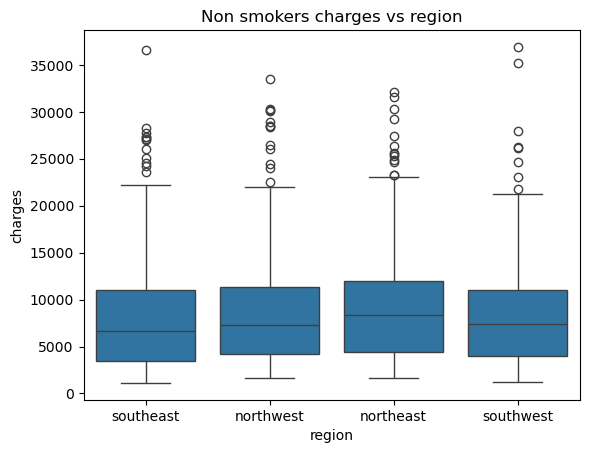

In [40]:
# Regional charges for non-smokers only — removes the dominant smoking signal
sns.boxplot(data=non_smokers_data, x="region", y="charges")
plt.title("Non smokers charges vs region")

Text(0.5, 1.0, 'Smokers charges vs region')

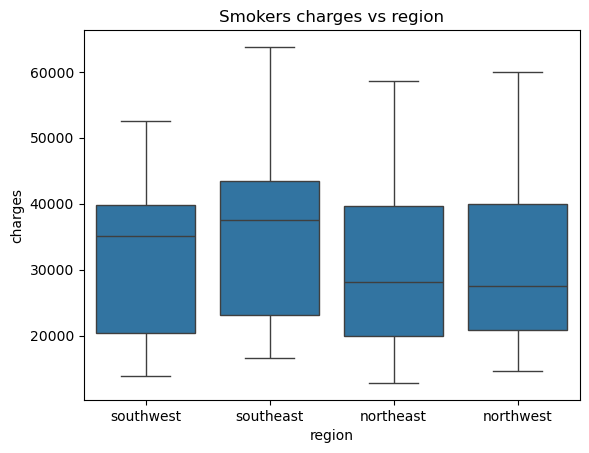

In [41]:
# Regional charges for smokers only — shows southern regions skew slightly higher
sns.boxplot(data=smokers_data, x="region", y="charges")
plt.title("Smokers charges vs region")

**So the mean values of charges for smoking men are slightly larger than form smoking women. Also mean charges for smoking person in south region 
are slightly higher than for people living in the north.**

**Now lets explore some potential outliers.**

<Axes: xlabel='bmi', ylabel='charges'>

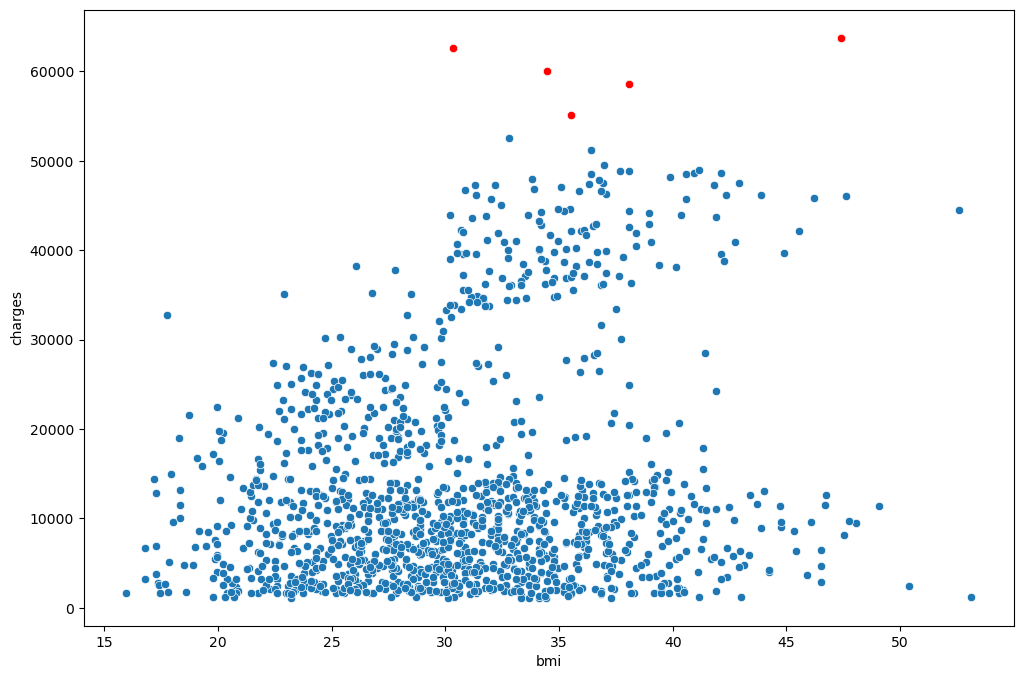

In [46]:
plt.figure(figsize=(12, 8))
# Base scatter: all points in the default blue colour
sns.scatterplot(data=df, x="bmi", y="charges")
# Overlay: highlight suspected high-charge outliers (charges ≥ $55,000) in red
sns.scatterplot(
    data=df,
    x=df[df["charges"] >= 55000]["bmi"],     # BMI values for those high-charge rows
    y=df[df["charges"] >= 55000]["charges"],  # Charge values for those same rows
    color="red"
)

In [47]:
# Inspect the full data for the high-charge rows flagged above
# Expect: all are smokers with high BMI (obesity) — biologically plausible, not errors
df[df["charges"] > 55000]

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.410,0,yes,southeast,63770.42801
577,31,female,38.095,1,yes,northeast,58571.07448
818,33,female,35.530,0,yes,northwest,55135.40209
1229,52,male,34.485,3,yes,northwest,60021.39897
1299,45,male,30.360,0,yes,southeast,62592.87309


**We can see that all of the people with the highest insurance charges are active smokers and have obesity, because optimal BMI for adult is between 19 and 25. Due to this and the fact, that data don't tell us about other illnesses, we are not going to remove that points.**

<Axes: xlabel='bmi', ylabel='charges'>

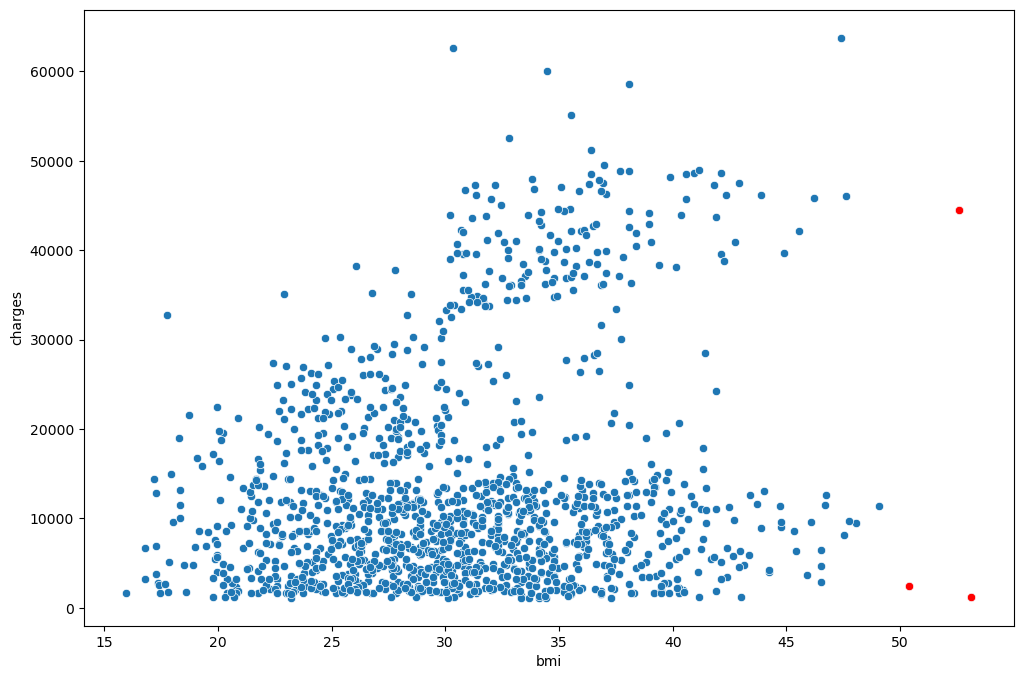

In [49]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x="bmi", y="charges")
# Highlight individuals with extremely high BMI (≥ 50) in red — potential data entry errors?
sns.scatterplot(
    data=df,
    x=df[df["bmi"] >= 50]["bmi"],      # x-axis: extreme-BMI values
    y=df[df["bmi"] >= 50]["charges"],  # y-axis: their corresponding charges
    color="red"
)

In [50]:
# Examine the extreme-BMI rows in detail
# BMI ≥ 50 is clinically classified as morbid obesity — unusual but medically possible
df[df["bmi"] >= 50]

,age,sex,bmi,children,smoker,region,charges
846,23,male,50.38,1,no,southeast,2438.0552
1046,22,male,52.58,1,yes,southeast,44501.3982
1316,18,male,53.13,0,no,southeast,1163.4627


In [51]:
# Retrieve the row index positions of extreme-BMI individuals
# Used in the next cell to overlay them on an age-vs-charges plot
df[df["bmi"] >= 50].index

Index([846, 1046, 1316], dtype='int64')

<Axes: xlabel='age', ylabel='charges'>

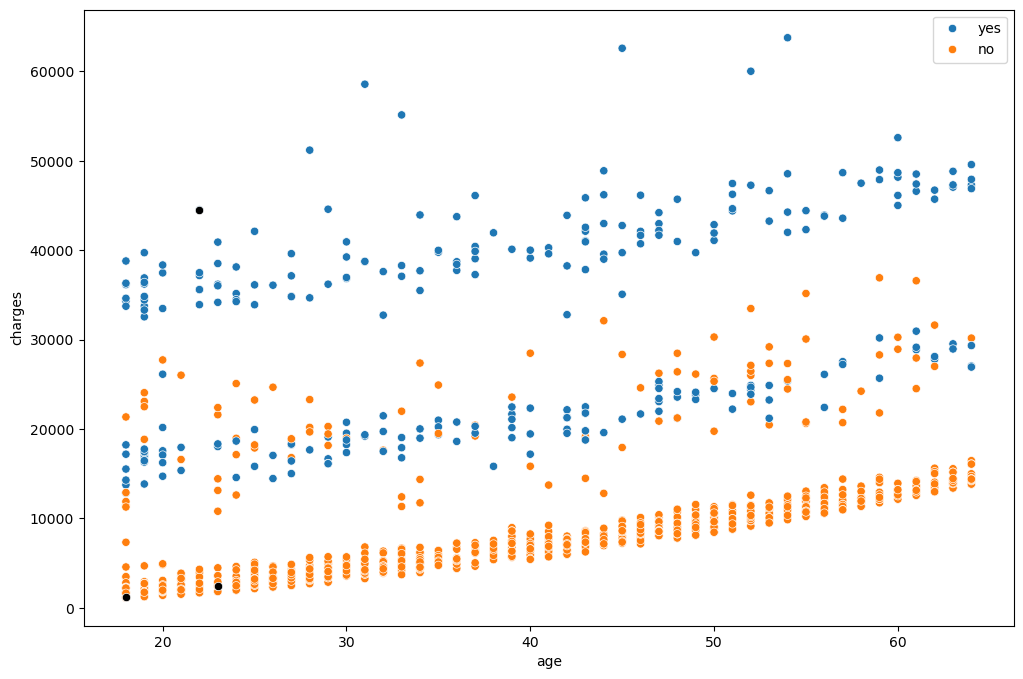

In [52]:
plt.figure(figsize=(12, 8))
# Main scatter: age vs charges coloured by smoker status
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")
# Overlay: extreme-BMI individuals in black — where do they fall in the age-charge space?
# If they scatter randomly among both clusters, BMI alone is not a dominant driver
sns.scatterplot(
    data=df,
    x=df[df["bmi"] >= 50]["age"],      # Age of high-BMI individuals
    y=df[df["bmi"] >= 50]["charges"],  # Charges of high-BMI individuals
    color="black"
)

**It looks like an obesity does not have such influence as being active smoker or an age of a beneficiary**

<Axes: xlabel='age', ylabel='bmi'>

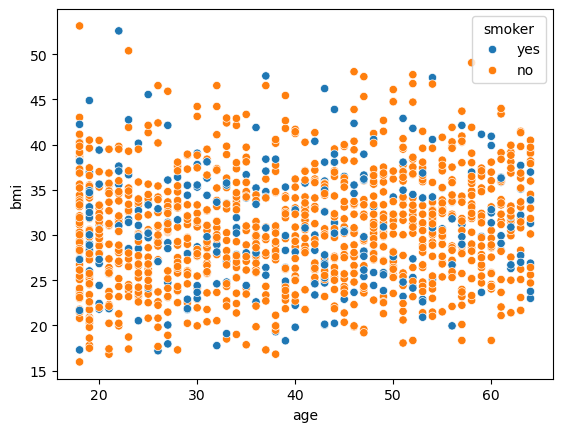

In [54]:
# Check if smoking status correlates with BMI — are smokers heavier on average?
# If not, smoking and BMI are largely independent features, both adding predictive value
sns.scatterplot(data=df, x="age", y="bmi", hue="smoker")

# We are not going to delete any data. We don't see significant outliers or values which are inappropriate with context.

**Now let's try to deal with categorical data.**

In [57]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.2+ KB


In [59]:
# Preparing OneHotEncoder to create dummy variables from categorical ones
#Firstly Train/Valdiation/Test split is made
encoder=OneHotEncoder()
X=df.drop(['charges'], axis=1)
y=df['charges']

In [60]:
X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.3, random_state=88)

In [61]:
X_validation, X_test, y_validation, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=88)

In [62]:
#Features are divided into 2 groups: categorical and numeric
Categorical_features=X_train.select_dtypes(include=['object', 'category']).columns.tolist()
Numeric_features=X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

In [63]:

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop='first' ), Categorical_features),
        ("num", StandardScaler(), Numeric_features)
    ]
)

In [64]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_validation_encoded = preprocessor.transform(X_validation)
X_test_encoded = preprocessor.transform(X_test)

In [65]:
feature_names = preprocessor.get_feature_names_out()

X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=feature_names,
    index=X_train.index
)
X_validation_encoded_df = pd.DataFrame(
    X_validation_encoded,
    columns=feature_names,
    index=X_validation.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=feature_names,
    index=X_test.index
)


In [66]:
train_corr_df = X_train_encoded_df.copy()
train_corr_df["charges"] = y_train

corr_with_target = (
    train_corr_df
    .corr()["charges"]
    .drop("charges")
    .sort_values(ascending=False)
)

print("Correlation with target:")
display(corr_with_target)

Correlation with target:


cat__smoker_yes          0.790860
num__age                 0.303490
num__bmi                 0.167093
cat__sex_male            0.085376
num__children            0.084132
cat__region_southeast    0.069928
cat__region_northwest   -0.048599
cat__region_southwest   -0.053432
Name: charges, dtype: float64

**First algorithm which we are going to consider is Linear Regression.**

In [68]:
help(LinearRegression)

Help on class LinearRegression in module sklearn.linear_model._base:

class LinearRegression(sklearn.base.MultiOutputMixin, sklearn.base.RegressorMixin, LinearModel)
 |  LinearRegression(*, fit_intercept=True, copy_X=True, n_jobs=None, positive=False)
 |
 |  Ordinary least squares Linear Regression.
 |
 |  LinearRegression fits a linear model with coefficients w = (w1, ..., wp)
 |  to minimize the residual sum of squares between the observed targets in
 |  the dataset, and the targets predicted by the linear approximation.
 |
 |  Parameters
 |  ----------
 |  fit_intercept : bool, default=True
 |      Whether to calculate the intercept for this model. If set
 |      to False, no intercept will be used in calculations
 |      (i.e. data is expected to be centered).
 |
 |  copy_X : bool, default=True
 |      If True, X will be copied; else, it may be overwritten.
 |
 |  n_jobs : int, default=None
 |      The number of jobs to use for the computation. This will only provide
 |      speedu

In [69]:
LinReg=LinearRegression()

In [70]:
LinReg.fit(X_train_encoded, y_train)

LinearRegression()

In [71]:
LinReg_predictions=LinReg.predict(X_validation_encoded)

In [72]:
LinReg_predictions

array([32667.96320087, 38202.47280354,  5233.5507993 ,  9268.81994294,
       15168.22318856,  9949.57680935,  9859.41579523,  7722.67909308,
       27916.7988687 ,  3570.81896056, 15134.65140646, 39905.60615564,
        4485.54212044, 33210.95717332,  7017.88692998, 12165.27973079,
        9339.21990819,  9136.73688555,  4287.34370328, 10669.99442322,
        3925.14268873, 29830.33354662, 14600.77579783, -1510.66870876,
        1770.80772902, 26846.37808005,  9461.5069019 ,  9925.12918014,
       12269.3432526 , 10378.07961678, 38076.66234509,  8539.39458526,
       13554.58278249,  3146.62076509,  2901.01089231,  6220.93789823,
        6721.85532188,  9169.99751673,  7196.43521371,  8292.13441743,
       15782.0675396 ,  4116.78024356, 25036.18918128, 10212.30527363,
        2082.81116338, 11104.27538008, 14269.60816425, 16435.29098134,
        7687.90504602, 10748.24284224, 12702.78381406, 34295.63665518,
       10835.07735424, 11156.04554225,  8379.18602455, 23948.92428401,
      

In [73]:
MAE_LinReg=mean_absolute_error(y_validation,LinReg_predictions)

In [74]:
MAE_LinReg

4277.0019616219615

In [75]:
MSE_LinReg= mean_squared_error(y_validation,LinReg_predictions)

In [76]:
MSE_LinReg

44236528.080586135

In [77]:
RMSE_LinReg=np.sqrt(MSE_LinReg)

In [78]:
RMSE_LinReg

6651.05465926917

In [79]:
y_validation.mean()

13468.041972139303

# **We see that RMSE around 6651 is not a good sign, when mean of insurance charges is 13468. It means that our model don't fit well.**


In [81]:
LINREG_BMI_values=X_validation_encoded_df["num__bmi"].values

In [82]:
LINREG_order=np.argsort(LINREG_BMI_values)
LINREG_order

array([ 23, 188, 189,  94,  59,  36, 150, 111, 145, 106,  91, 163,  55,
        77, 169,  39,  38,  84, 175,  75, 104,  44, 174,  48,   7,  61,
       118,  20,  17, 147, 149, 158, 170, 138, 184, 193,  16, 108, 126,
        54, 190, 194,  24,  82,   6, 176,  60,  97, 156, 114, 185,  95,
        67, 129, 105,  90,   5, 119, 130,   3,  96, 167,  83,  45, 161,
         2,  98, 137, 122, 153, 102, 133, 142,  68,  79, 159,  42, 124,
        86, 200,  25, 141,  18, 109, 173, 160, 125, 136,  74,  85,  99,
       148,  35,  29, 162,  70, 113,  15, 191,  53, 171,  64,  27,  56,
       135,  26, 140, 199, 132, 178, 165,  28,  19,  13, 110,  12,  69,
       177,  92, 100,  41,  66,   9,  32,  37, 154,  52,  65,  57, 128,
        46,  81, 164, 107, 197,  50,  34, 144,  71,  31, 186,  63, 151,
       180,  72,  89, 196,  30, 166, 182,  33,  78, 117, 115,  87, 168,
         4,  43,  51, 192,  22,   0, 121,   1,  21, 131, 183, 187, 181,
        93, 134, 152, 172,  88, 195, 127, 179, 123,  80,  62, 13

In [83]:
LINREG_BMI_sorted=LINREG_BMI_values[LINREG_order]
LINREG_BMI_sorted

array([-2.42315793, -2.28218156, -2.17253327, -2.00435094, -1.90624458,
       -1.82792437, -1.74960417, -1.73558897, -1.70755858, -1.69107012,
       -1.62676511, -1.59049049, -1.48331547, -1.46765143, -1.3423391 ,
       -1.32667506, -1.31101102, -1.28215621, -1.23269081, -1.20136273,
       -1.15437061, -1.13870657, -1.10737848, -1.1007831 , -1.08099694,
       -1.0760504 , -1.0760504 , -1.04637117, -1.04472232, -1.02905828,
       -1.01339424, -1.01009655, -0.98206616, -0.98206616, -0.96640212,
       -0.91940999, -0.90374595, -0.88313537, -0.85675383, -0.83366998,
       -0.81058613, -0.81058613, -0.80976171, -0.80069305, -0.79409766,
       -0.79409766, -0.78420459, -0.7561742 , -0.7314415 , -0.71577746,
       -0.70176226, -0.68362495, -0.65312129, -0.63580841, -0.63580841,
       -0.57480109, -0.54347301, -0.54347301, -0.52780897, -0.52038916,
       -0.52038916, -0.49648088, -0.49648088, -0.49648088, -0.48741223,
       -0.48411454, -0.48411454, -0.48081684, -0.4651528 , -0.44

In [84]:
LinReg_predictions[LINREG_order]

array([-1510.66870876,   189.72702287, -1480.47093445,  2486.77734129,
       28017.13298332,  6721.85532188, 26680.25730394, 29679.17837951,
       -1137.40872681,  1891.45353783,  -914.86848447,  9137.17510753,
       23948.92428401,  2971.37990082,   209.49338712,  8292.13441743,
        7196.43521371, 32599.37339219,  1856.87313992, 30475.40856205,
       34119.30817075,  2082.81116338,  7271.03993268,  7687.90504602,
        7722.67909308, 33076.64129814,  3890.53803111,  3925.14268873,
        9136.73688555, 10901.00432917,  1387.41813318, 10738.53059957,
       12561.30636458, 11445.0967594 ,  9969.71194453,  1447.4304298 ,
        9339.21990819, 29035.77332487, 12239.63190963,  8379.18602455,
       10987.24484155,  2243.60733792,  1770.80772902,  9249.69471413,
        9859.41579523, 33289.72244806,  3226.13459828, 30714.7523769 ,
       10221.2330032 ,  7067.02484456, 29136.41682806,  1983.00733731,
       13175.65756082, 10559.4044914 ,  4055.14981136,  8810.08370931,
      

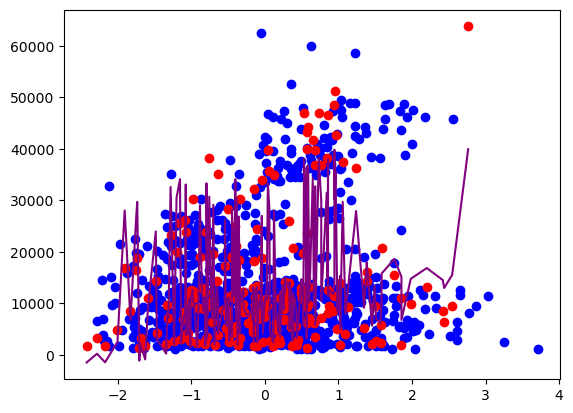

In [85]:
# 2D projection of the multi-dimensional linear regression model
# Our model lives in n-dimensional space (one dimension per feature)
# What we see here is the 'shadow' of that hyperplane projected onto the BMI axis
# Blue  = training data (actual charges vs BMI)
# Red   = validation data (actual charges vs BMI)
# Purple line = model's predictions at each BMI value in the validation set
plt.scatter(x=X_train_encoded_df["num__bmi"],y=y_train, color="blue", label="Actual")
plt.scatter(x=LINREG_BMI_sorted,y=y_validation.values[LINREG_order], color="red", label="Validation")
plt.plot(LINREG_BMI_sorted, LinReg_predictions[LINREG_order], color="purple")

**Above it is a showcase, that linear regression model for many features doesn't return straight line in 2D scatter plots. The reason is that our model is built for many variables, and we get the "straight line" in n-dimensional chart, which is not able to draw in our case. This what we see is a projection from n-dimensions to 2D.**

**Much better option is to draw predicted values and compare them to the real ones.**

In [88]:
x=np.linspace(0,60000,60000)



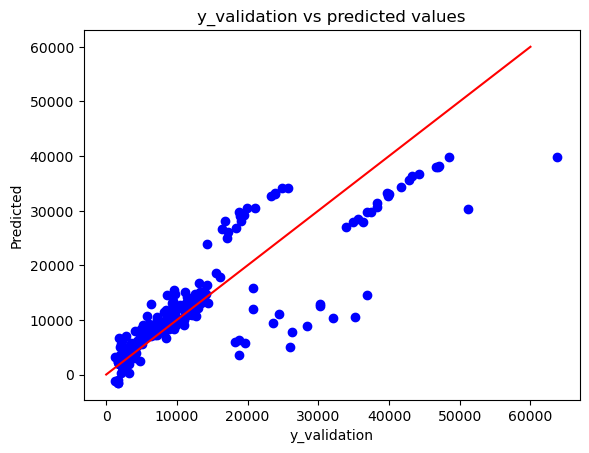

In [89]:
# Predicted vs Actual plot — the gold standard diagnostic for regression models
# Perfect model: all points lie exactly on the red diagonal line (predicted = actual)
# Points above diagonal → model over-predicted; below → model under-predictedplt.figure(figsize=(10,6))
plt.scatter(x=y_validation, y=LinReg_predictions, color="blue")
plt.title("y_validation vs predicted values")
plt.xlabel("y_validation")
plt.ylabel("Predicted")
plt.plot(x,x, color="red")

In [90]:
Res=LinReg_predictions-y_validation

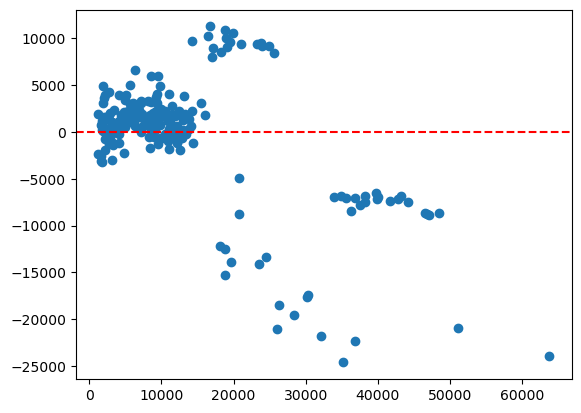

In [91]:
# Residuals = predicted - actual
# Positive residual -> model over-predicted for that patient
# Negative residual -> model under-predicted
plt.scatter(x=y_validation, y=Res)
plt.axhline(y=0, color="red", linestyle='--')

**Residuals are not randomly distributed. We see clear trends. This confirms us, that Linear Regression does not fill well for solving this problem.**

# In this chapter we will dive into Polynomial Regression

At the beggining we need to change our features and then scale them. This is because if we scale features first, we will likely create some negative numbers. Changing the features to a higher dimension will create even degrees of the polynomial. As a result, the negative numbers will turn positive, completely distorting the information about the data.

In [95]:
train_rmse_errors=[]
validation_rmse_errors=[]

We are going to use the Elbow method to figure out which degree of the polynomial fit the best.

In [97]:
for d in range(1,10):
    numeric_poly_pipeline = Pipeline(steps=[
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scaler", StandardScaler())
        ])
    poly_preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                Categorical_features
            ),
            (
                "num",
                numeric_poly_pipeline,
                Numeric_features
            )
        ]
    )
    poly_model = Pipeline(steps=[
        ("preprocessor", poly_preprocessor),
        ("model", LinearRegression())
    ])
    poly_model.fit(X_train, y_train)
    train_pred = poly_model.predict(X_train)
    validation_pred = poly_model.predict(X_validation)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    validation_rmse = np.sqrt(mean_squared_error(y_validation, validation_pred))
    train_rmse_errors.append(train_rmse)
    validation_rmse_errors.append(validation_rmse)
    print(f"Degree: {d} | Train RMSE: {train_rmse:.2f} | Validation RMSE: {validation_rmse:.2f}")

    

Degree: 1 | Train RMSE: 5848.73 | Validation RMSE: 6651.05
Degree: 2 | Train RMSE: 5769.19 | Validation RMSE: 6612.21
Degree: 3 | Train RMSE: 5647.47 | Validation RMSE: 6778.42
Degree: 4 | Train RMSE: 5611.95 | Validation RMSE: 6738.01
Degree: 5 | Train RMSE: 5548.19 | Validation RMSE: 6674.29
Degree: 6 | Train RMSE: 5415.05 | Validation RMSE: 6562.94
Degree: 7 | Train RMSE: 5300.02 | Validation RMSE: 6809.49
Degree: 8 | Train RMSE: 5180.46 | Validation RMSE: 7125.37
Degree: 9 | Train RMSE: 5066.79 | Validation RMSE: 33848.13


In [98]:
train_rmse_errors

[5848.725865498092,
 5769.188846021783,
 5647.4685764545475,
 5611.951001400551,
 5548.187181628367,
 5415.048391369812,
 5300.016499421161,
 5180.457069736532,
 5066.788769718592]

In [99]:
validation_rmse_errors

[6651.05465926917,
 6612.209765454195,
 6778.417704821588,
 6738.012376576977,
 6674.29100183685,
 6562.944982029139,
 6809.4860414225805,
 7125.37378099403,
 33848.13068141284]

In [100]:
Dict={'train_rmse_errors':train_rmse_errors , 'validation_rmse_errors':validation_rmse_errors}

In [101]:
Elbow_df=pd.DataFrame(Dict)
Elbow_df

,train_rmse_errors,validation_rmse_errors
0,5848.725865,6651.054659
1,5769.188846,6612.209765
2,5647.468576,6778.417705
3,5611.951001,6738.012377
4,5548.187182,6674.291002
5,5415.048391,6562.944982
6,5300.016499,6809.486041
7,5180.457070,7125.373781
8,5066.788770,33848.130681


In [102]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [103]:
Elbow_df

,train_rmse_errors,validation_rmse_errors
0,5848.73,6651.05
1,5769.19,6612.21
2,5647.47,6778.42
3,5611.95,6738.01
4,5548.19,6674.29
5,5415.05,6562.94
6,5300.02,6809.49
7,5180.46,7125.37
8,5066.79,33848.13


In [104]:
Elbow_df.index.to_list()

[0, 1, 2, 3, 4, 5, 6, 7, 8]

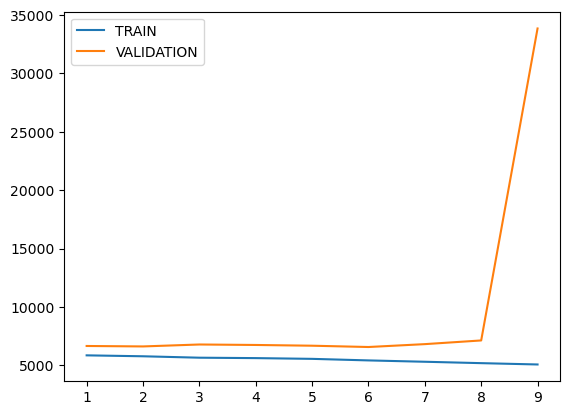

In [184]:
plt.plot(range(1,10), train_rmse_errors, label="TRAIN")
plt.plot(range(1,10), validation_rmse_errors, label="VALIDATION")
plt.legend()

**From Elbow method we conclude that there are no significantly better degrees than 1 for linear regression.**

# In the next step, we are going to check how regularization affects on model and how SVR and RandomForestRegressor deal with our situation. We will also use GridSearch and create Pipeline to find parameteres.

In [188]:
numeric_poly_pipeline = Pipeline(steps=[
        ("poly", PolynomialFeatures()),
        ("scaler", StandardScaler())
]
    )

Grid_preprocessor=ColumnTransformer( transformers = [
            (
                "cat",
                OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                Categorical_features
            ),
            (
                "num",
                numeric_poly_pipeline,
                Numeric_features
            )
        ]
    )


In [223]:
models_and_params={
    "LinearRegression":{
        "model": LinearRegression(),
        "params":{
            "Grid_preprocessor__num__poly__degree":[1,2,3,4]}
    },
    "ElasticNet":{
        "model":ElasticNet(),
        "params":{
            "Grid_preprocessor__num__poly__degree":[1,2,3,4],
            "model__alpha":[0.001,0.01,0.05,0.1,0.5,1,5,10],
            "model__l1_ratio":[0,0.1,0.3,0.5,0.7,1],
            "model__fit_intercept":[True, False]
            
        }
    },
    "SVR":{
        "model":SVR(),
        "params":{
            "Grid_preprocessor__num__poly__degree":[1,2,3,4],
            "model__kernel":['poly','rbf'],
            "model__C": [0.1, 1, 10, 100],
            "model__epsilon": [0.1, 0.5, 1],
        }
    },
     "RandomForest": {
        "model": RandomForestRegressor(random_state=88),
        "params": {
            "Grid_preprocessor__num__poly__degree": [1],
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_split": [2, 5, 10]
        }
    }
}
    
            
    

In [201]:
models_and_params.keys()

dict_keys(['LinearRegression', 'ElasticNet', 'SVR', 'RandomForest'])

In [203]:
models_and_params.items()

dict_items([('LinearRegression', {'model': LinearRegression(), 'params': {'Grid_preprocessor__num__poly__degree': [1, 2, 3, 4]}}), ('ElasticNet', {'model': ElasticNet(), 'params': {'Grid_preprocessor__num__poly__degree': [1, 2, 3, 4], 'model__alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10], 'model__l1_ratio': [0, 0.1, 0.3, 0.5, 0.7, 1], 'model__fit_intercept': [True, False]}}), ('SVR', {'model': SVR(), 'params': {'Grid_preprocessor__num__poly__degree': [1, 2, 3, 4], 'model__kernel': ['poly', 'rbf'], 'model__C': [0.1, 1, 10, 100], 'model__epsilon': [0.1, 0.5, 1]}}), ('RandomForest', {'model': RandomForestRegressor(random_state=88), 'params': {'preprocessor__num__poly__degree': [1], 'model__n_estimators': [100, 200], 'model__max_depth': [None, 5, 10], 'model__min_samples_split': [2, 5, 10]}})])

**Now we can create Pipeline and GridSearch model.**

In [197]:
Models_results=[]

In [369]:
for model_name, config in models_and_params.items():
    model_pipe=Pipeline(steps=[
        ("Grid_preprocessor", Grid_preprocessor),
        ("model", config["model"])
    ])

    Grid = GridSearchCV( estimator= model_pipe,
                        param_grid=config["params"],
                        scoring="neg_root_mean_squared_error",
                        cv=5)
    Grid.fit(X_train, y_train)

    validation_pred=Grid.predict(X_validation)
    train_pred = Grid.predict(X_train)

    validation_rmse=np.sqrt(mean_squared_error(y_validation, validation_pred))
    train_rmse=np.sqrt(mean_squared_error(y_train, train_pred))

    Models_results.append({
        "model":model_name,
        "best_cv_rmse": -Grid.best_score_,
        "train_rmse": train_rmse,
        "validation_rmse": validation_rmse,
        "best_params": Grid.best_params_,
        "best_estimator":Grid.best_estimator_}
                         )
                        
    print(f"{model_name}")
    print("Best CV RMSE:", -Grid.best_score_)
    print("Train RMSE:", train_rmse)
    print("Validation RMSE:", validation_rmse)
    print("Best params:", Grid.best_params_)
    print("-" * 60)               

LinearRegression
Best CV RMSE: 5851.8437089708195
Train RMSE: 5647.4685764545475
Validation RMSE: 6778.417704821588
Best params: {'Grid_preprocessor__num__poly__degree': 3}
------------------------------------------------------------


C:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.294e+10, tolerance: 1.043e+07 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.276e+10, tolerance: 9.981e+06 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV in

ElasticNet
Best CV RMSE: 5828.878139484696
Train RMSE: 5648.610698335441
Validation RMSE: 6713.624085720384
Best params: {'Grid_preprocessor__num__poly__degree': 4, 'model__alpha': 0.001, 'model__fit_intercept': True, 'model__l1_ratio': 0.5}
------------------------------------------------------------
SVR
Best CV RMSE: 11229.079351312508
Train RMSE: 11028.943510833828
Validation RMSE: 11612.855868767781
Best params: {'Grid_preprocessor__num__poly__degree': 1, 'model__C': 100, 'model__epsilon': 0.1, 'model__kernel': 'poly'}
------------------------------------------------------------
RandomForest
Best CV RMSE: 4352.949068201489
Train RMSE: 3716.085279608797
Validation RMSE: 5322.422978379818
Best params: {'Grid_preprocessor__num__poly__degree': 1, 'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 200}
------------------------------------------------------------


KeyboardInterrupt: 

In [266]:
results_df=pd.DataFrame(data=Models_results).sort_values("validation_rmse")


In [268]:
results_df.index = range(1, 8)
display(results_df)

,model,best_cv_rmse,validation_rmse,best_params,best_estimator
1,RandomForest,4352.95,5322.42,"{'Grid_preprocessor__num__poly__degree': 1, 'm...","(ColumnTransformer(transformers=[('cat',\n ..."
2,ElasticNet,5828.88,6713.62,"{'Grid_preprocessor__num__poly__degree': 4, 'm...","(ColumnTransformer(transformers=[('cat',\n ..."
3,ElasticNet,5828.88,6713.62,"{'Grid_preprocessor__num__poly__degree': 4, 'm...","(ColumnTransformer(transformers=[('cat',\n ..."
4,LinearRegression,5851.84,6778.42,{'Grid_preprocessor__num__poly__degree': 3},"(ColumnTransformer(transformers=[('cat',\n ..."
5,LinearRegression,5851.84,6778.42,{'Grid_preprocessor__num__poly__degree': 3},"(ColumnTransformer(transformers=[('cat',\n ..."
6,SVR,11229.08,11612.86,"{'Grid_preprocessor__num__poly__degree': 1, 'm...","(ColumnTransformer(transformers=[('cat',\n ..."
7,SVR,11229.08,11612.86,"{'Grid_preprocessor__num__poly__degree': 1, 'm...","(ColumnTransformer(transformers=[('cat',\n ..."


**We see that RandomForest algorithm is the best one, so lets try to explore this one more.**


In [290]:
RF_params={"Grid_preprocessor__num__poly__degree": [1],
            "model__n_estimators": [150, 200, 225, 250, 300],
            "model__max_depth": [None, 2, 4, 5, 7, 10, 15],
            "model__min_samples_split": [2, 3, 4, 5],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", 1.0]}

In [292]:
RF_pipe=Pipeline(steps=[
        ("Grid_preprocessor", Grid_preprocessor),
        ("model", RandomForestRegressor(random_state=88))])

In [294]:
grid_RF=GridSearchCV(estimator=RF_pipe,
                     param_grid=RF_params,
                     scoring="neg_root_mean_squared_error",
                     cv=5)

In [296]:
grid_RF.fit(X_train, y_train)
RF_validation_pred=grid_RF.predict(X_validation)
RF_validation_rmse=np.sqrt(mean_squared_error(y_validation, RF_validation_pred))

In [304]:

    print("Best CV RMSE:", -grid_RF.best_score_)
    print("Validation RMSE:", RF_validation_rmse)
    print("Best params:", grid_RF.best_params_)
    print("-" * 60)   

Best CV RMSE: 4314.3699946601255
Validation RMSE: 5305.027793064759
Best params: {'Grid_preprocessor__num__poly__degree': 1, 'model__max_depth': 4, 'model__max_features': 1.0, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}
------------------------------------------------------------


**Our research does not seem to improve RandomForestRegressor model, so lets switch to the last model: XGBoost.**

In [310]:
XGBPipe= Pipeline(steps=[
    ("Grid_preprocessor", Grid_preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=88,
        tree_method="hist",
        eval_metric="rmse"
    ))
])

In [314]:
XGB_params = {
    "Grid_preprocessor__num__poly__degree": [1],
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__reg_lambda": [1, 3, 5, 10],
    "model__min_child_weight": [1, 3, 5]
}

In [316]:
xgb_search = RandomizedSearchCV(
    estimator=XGBPipe,
    param_distributions=XGB_params,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=88,
    verbose=2
)

In [318]:
xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END Grid_preprocessor__num__poly__degree=1, model__colsample_bytree=0.7, model__learning_rate=0.1, model__max_depth=3, model__min_child_weight=5, model__n_estimators=500, model__reg_lambda=3, model__subsample=0.8; total time=   0.4s
[CV] END Grid_preprocessor__num__poly__degree=1, model__colsample_bytree=0.7, model__learning_rate=0.1, model__max_depth=3, model__min_child_weight=5, model__n_estimators=500, model__reg_lambda=3, model__subsample=0.8; total time=   0.2s
[CV] END Grid_preprocessor__num__poly__degree=1, model__colsample_bytree=0.7, model__learning_rate=0.1, model__max_depth=3, model__min_child_weight=5, model__n_estimators=500, model__reg_lambda=3, model__subsample=0.8; total time=   0.3s
[CV] END Grid_preprocessor__num__poly__degree=1, model__colsample_bytree=0.7, model__learning_rate=0.1, model__max_depth=3, model__min_child_weight=5, model__n_estimators=500, model__reg_lambda=3, model__subsample=0.8; total

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('Grid_preprocessor',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               ['sex',
                                                                                'smoker',
                                                                                'region']),
                                                                              ('num',
                                                                               Pipeline(steps=[('poly',
                                                                                                PolynomialFeatures()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['age',
                                                                                'bmi',
                                                                                'children'])])),
                                             ('model',
                                              XGBRegressor(base_sc...
                   param_distributions={'Grid_preprocessor__num__poly__degree': [1],
                                        'model__colsample_bytree': [0.7, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [2, 3, 4, 5],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [100, 200, 300,
                                                                500],
                                        'model__reg_lambda': [1, 3, 5, 10],
                                        'model__subsample': [0.7, 0.8, 1.0]},
                   random_state=88, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [320]:
print("Best params:", xgb_search.best_params_)
print("Best CV RMSE:", -xgb_search.best_score_)

Best params: {'model__subsample': 0.7, 'model__reg_lambda': 10, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 2, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0, 'Grid_preprocessor__num__poly__degree': 1}
Best CV RMSE: 4328.402110081848


In [322]:
xgb_validation_pred = xgb_search.predict(X_validation)

xgb_validation_rmse = np.sqrt(
    mean_squared_error(y_validation, xgb_validation_pred)
)

print("XGBoost Validation RMSE:", xgb_validation_rmse)

XGBoost Validation RMSE: 5319.874105096501


**XGBoost also does not work significantly better than RandomForestRegressor, so now lets switch to the last idea. 
The y values are skew, so we are going to scale them by logarithm.**

In [355]:
models_and_params2={
    "LinearRegression":{
        "model": LinearRegression(),
        "search_type": "grid",
        "params":{
            "regressor__Grid_preprocessor__num__poly__degree":[1,2,3,4]}
    },
    "ElasticNet":{
        "model":ElasticNet(),
        "search_type": "grid",
        "params":{
            "regressor__Grid_preprocessor__num__poly__degree":[1,2,3,4],
            "regressor__model__alpha":[0.001,0.01,0.05,0.1,0.5,1,5,10],
            "regressor__model__l1_ratio":[0,0.1,0.3,0.5,0.7,1],
            "regressor__model__fit_intercept":[True, False]
            
        }
    },
    "SVR":{
        "model":SVR(),
        "search_type": "grid",
        "params":{
            "regressor__Grid_preprocessor__num__poly__degree":[1,2,3,4],
            "regressor__model__kernel":['poly','rbf'],
            "regressor__model__C": [0.1, 1, 10, 100],
            "regressor__model__epsilon": [0.1, 0.5, 1],
        }
    },
     "RandomForest": {
        "model": RandomForestRegressor(random_state=88),
        "search_type": "grid",
        "params": {
            "regressor__Grid_preprocessor__num__poly__degree": [1],
            "regressor__model__n_estimators": [100, 200],
            "regressor__model__max_depth": [None, 5, 10],
            "regressor__model__min_samples_split": [2, 5, 10]
        }
    },
    "XGBRegressor":{
        "model": XGBRegressor(
        objective="reg:squarederror",
        random_state=88,
        tree_method="hist",
        eval_metric="rmse"),
        "search_type": "rand",
        "n_iter": 50,
        "params": {
            "regressor__Grid_preprocessor__num__poly__degree": [1],
            "regressor__model__n_estimators": [100, 200, 300, 500],
            "regressor__model__max_depth": [2, 3, 4, 5],
            "regressor__model__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "regressor__model__subsample": [0.7, 0.8, 1.0],
            "regressor__model__colsample_bytree": [0.7, 0.8, 1.0],
            "regressor__model__reg_lambda": [1, 3, 5, 10],
            "regressor__model__min_child_weight": [1, 3, 5]
        }
    }}
    

In [335]:
models_eval1=[]

In [359]:
for model_name, config in models_and_params2.items():
    
    Logpipe = Pipeline(steps=[
    ("Grid_preprocessor", Grid_preprocessor),
    ("model", config["model"])
    ])

    log_target_model = TransformedTargetRegressor(
    regressor=Logpipe,
    func=np.log1p,
    inverse_func=np.expm1)

    if config["search_type"]== "grid":
        search =GridSearchCV(
            estimator= log_target_model,
            param_grid=config["params"],
            scoring="neg_root_mean_squared_error",
            cv=5)
    elif config["search_type"] == "rand":
        search = RandomizedSearchCV(
            estimator=log_target_model,
            param_distributions=config["params"],
            n_iter=config["n_iter"],
            scoring="neg_root_mean_squared_error",
            cv=5,
            random_state=88,
            verbose=1
        )
    search.fit(X_train, y_train)
    
    train_pred = search.predict(X_train)
    validation_pred = search.predict(X_validation)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    validation_rmse = np.sqrt(mean_squared_error(y_validation, validation_pred))
    

    
    models_eval1.append({
        "model": model_name,
        "train_rmse": train_rmse,
        "validation_rmse": validation_rmse,
        "best_cv_rmse": -search.best_score_,
        "best_params": search.best_params_,
        "best_estimator": search.best_estimator_
    })
    
    print(model_name)
    print("Train RMSE:", train_rmse)
    print("Validation RMSE:", validation_rmse)
    print("Best CV RMSE:", -search.best_score_)
    print("Best params:", search.best_params_)
    print("-" * 80)

    

LinearRegression
Train RMSE: 7467.157762392789
Validation RMSE: 7701.6840103886325
Best CV RMSE: 7629.992400121099
Best params: {'regressor__Grid_preprocessor__num__poly__degree': 3}
--------------------------------------------------------------------------------


C:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.208e+01, tolerance: 6.303e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.605e+01, tolerance: 6.220e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV in

ElasticNet
Train RMSE: 7260.137054742406
Validation RMSE: 7707.408869684263
Best CV RMSE: 7291.739648349906
Best params: {'regressor__Grid_preprocessor__num__poly__degree': 3, 'regressor__model__alpha': 0.05, 'regressor__model__fit_intercept': True, 'regressor__model__l1_ratio': 1}
--------------------------------------------------------------------------------
SVR
Train RMSE: 4467.265615292021
Validation RMSE: 5821.319781534611
Best CV RMSE: 4980.219852595422
Best params: {'regressor__Grid_preprocessor__num__poly__degree': 1, 'regressor__model__C': 1, 'regressor__model__epsilon': 0.1, 'regressor__model__kernel': 'rbf'}
--------------------------------------------------------------------------------
RandomForest
Train RMSE: 3960.749984244901
Validation RMSE: 5274.9871510543635
Best CV RMSE: 4353.805887740998
Best params: {'regressor__Grid_preprocessor__num__poly__degree': 1, 'regressor__model__max_depth': 5, 'regressor__model__min_samples_split': 5, 'regressor__model__n_estimators': 20

In [361]:
print("Train size:", len(y_train))
print("Validation size:", len(y_validation))
print("Test size:", len(y_test))

summary = pd.DataFrame({
    "train": y_train.describe(),
    "validation": y_validation.describe(),
    "test": y_test.describe()
})

display(summary)


Train size: 935
Validation size: 201
Test size: 201


,train,validation,test
count,935.00,201.00,201.00
mean,12913.79,13468.04,14789.64
std,11777.71,12250.19,13374.53
min,1121.87,1242.26,1141.45
25%,4718.86,5003.85,4889.04
50%,9182.17,9566.99,9875.68
75%,15013.17,17081.08,19749.38
max,62592.87,63770.43,55135.40


In [363]:
display(y_train.sort_values(ascending=False).head(10))
display(y_validation.sort_values(ascending=False).head(10))
display(y_test.sort_values(ascending=False).head(10))

1299   62592.87
1229   60021.40
577    58571.07
1145   52590.83
1240   49577.66
488    48885.14
175    48824.45
530    48675.52
900    48673.56
281    48549.18
Name: charges, dtype: float64

543    63770.43
34     51194.56
330    48517.56
109    47055.53
420    46889.26
421    46599.11
252    44260.75
741    43254.42
327    42760.50
1217   41661.60
Name: charges, dtype: float64

818    55135.40
1061   48970.25
39     48173.36
94     47291.06
1121   46661.44
859    46113.51
1095   44641.20
1046   44501.40
1030   44423.80
586    43943.88
Name: charges, dtype: float64

In [365]:
print("Train smoker distribution:")
display(X_train["smoker"].value_counts(normalize=True))

print("Validation smoker distribution:")
display(X_validation["smoker"].value_counts(normalize=True))

print("Test smoker distribution:")
display(X_test["smoker"].value_counts(normalize=True))

Train smoker distribution:


smoker
no    0.80
yes   0.20
Name: proportion, dtype: float64

Validation smoker distribution:


smoker
no    0.81
yes   0.19
Name: proportion, dtype: float64

Test smoker distribution:


smoker
no    0.75
yes   0.25
Name: proportion, dtype: float64

In [367]:
y.mean()

13279.121486655948

**The RandomForest model with log-transformed target achieved the lowest validation RMSE. Although its training RMSE was slightly higher than the standard RandomForest model, it showed better validation performance and a smaller train-validation gap, suggesting better generalization. Therefore, it was selected as the final model.**

In [372]:
models_eval_df=pd.DataFrame(data=models_eval1).sort_values("validation_rmse")

In [374]:
models_eval_df.head(7)

,model,train_rmse,validation_rmse,best_cv_rmse,best_params,best_estimator
3,RandomForest,3960.75,5274.99,4353.81,{'regressor__Grid_preprocessor__num__poly__deg...,TransformedTargetRegressor(func=<ufunc 'log1p'...
4,XGBRegressor,3847.63,5386.53,4364.62,"{'regressor__model__subsample': 1.0, 'regresso...",TransformedTargetRegressor(func=<ufunc 'log1p'...
2,SVR,4467.27,5821.32,4980.22,{'regressor__Grid_preprocessor__num__poly__deg...,TransformedTargetRegressor(func=<ufunc 'log1p'...
0,LinearRegression,7467.16,7701.68,7629.99,{'regressor__Grid_preprocessor__num__poly__deg...,TransformedTargetRegressor(func=<ufunc 'log1p'...
1,ElasticNet,7260.14,7707.41,7291.74,{'regressor__Grid_preprocessor__num__poly__deg...,TransformedTargetRegressor(func=<ufunc 'log1p'...


In [404]:
Best_model=models_eval_df.loc[models_eval_df["model"]=="RandomForest", "best_estimator"].iloc[0]

In [406]:
Best_model.fit(X_train, y_train)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('Grid_preprocessor',
                                                      ColumnTransformer(transformers=[('cat',
                                                                                       OneHotEncoder(drop='first',
                                                                                                     handle_unknown='ignore',
                                                                                                     sparse_output=False),
                                                                                       ['sex',
                                                                                        'smoker',
                                                                                        'region']),
                                                                                      ('num',
                                                                                       Pipeline(steps=[('poly',
                                                                                                        PolynomialFeatures(degree=1)),
                                                                                                       ('scaler',
                                                                                                        StandardScaler())]),
                                                                                       ['age',
                                                                                        'bmi',
                                                                                        'children'])])),
                                                     ('model',
                                                      RandomForestRegressor(max_depth=5,
                                                                            min_samples_split=5,
                                                                            n_estimators=200,
                                                                            random_state=88))]))

In [408]:
test_pred=Best_model.predict(X_test)

In [410]:
test_rmse =np.sqrt(mean_squared_error(y_test, test_pred))
test_mae= mean_absolute_error(y_test, test_pred)

In [412]:
print("Final Test RMSE:", test_rmse)
print("Final Test MAE:", test_mae)

Final Test RMSE: 4611.43783934878
Final Test MAE: 2132.0641927602155


**The final model was a RandomForestRegressor with a log-transformed target variable using TransformedTargetRegressor. It achieved a final test RMSE of 4611.44 and a test MAE of 2132.06. The MAE indicates that the model's average absolute prediction error was approximately 2132 insurance charge units. The RMSE was higher than MAE, suggesting that some high-cost cases still produced larger errors, which is expected due to the right-skewed distribution of the target variable.**

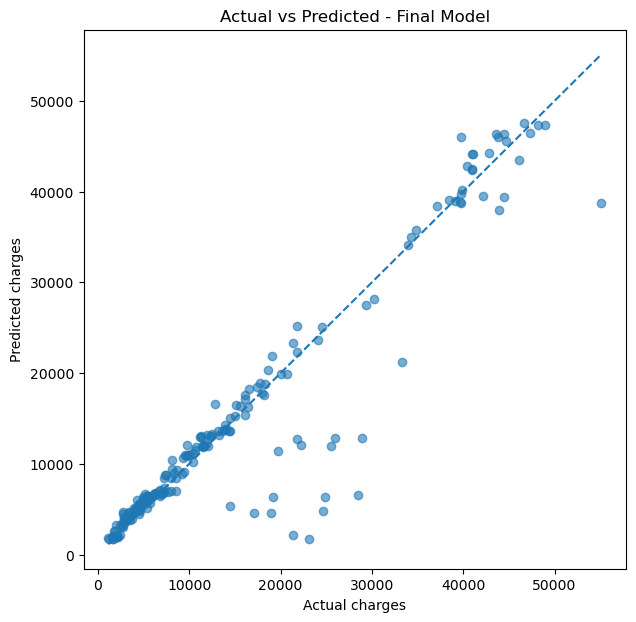

In [415]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
plt.title("Actual vs Predicted - Final Model")
plt.show()

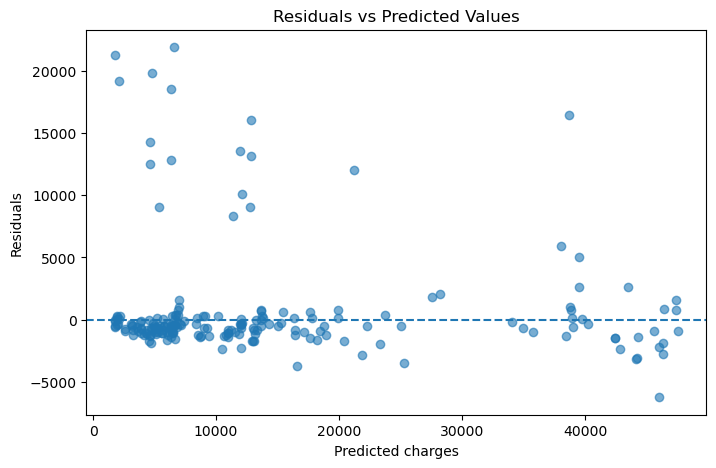

In [417]:
residuals = y_test - test_pred

plt.figure(figsize=(8, 5))
plt.scatter(test_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()